**Mini Batch GD**

Mini-batch gradient descent is an optimization algorithm that updates model parameters by calculating gradients on small, random subsets (mini-batches) of the training data. It bridges the efficiency of batch gradient descent with the speed of stochastic gradient descent (SGD), offering faster convergence, reduced memory usage, and stable, smoother updates, commonly using batch sizes like 32–512

* Batch GD is too slow because it waits for the whole dataset.
* SGD is too "jumpy" because it only looks at one row, which can lead to inefficient paths.
* Mini-batch GD splits the data into small groups (called batches), typically in sizes of 32, 64, or 128.

**The Benefits:**
* Vectorization: Modern CPUs and GPUs are optimized for matrix math. Processing 32 rows at once is often just as fast as processing 1 row because of parallel computing.
* Smoother Convergence: By averaging the gradient over a batch, the path to the minimum is much less "noisy" than SGD.
* Memory Efficiency: You only need to load one batch into memory at a time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target.reshape(-1, 1)
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

n_samples, n_features = X_std.shape
weights = np.zeros((n_features, 1))
bias = 0

learning_rate = 0.05
epochs = 100
batch_size = 32 

loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(n_samples)
    X_shuffled = X_std[indices]
    y_shuffled = y[indices]
    
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        m = X_batch.shape[0] 

        y_pred = np.dot(X_batch, weights) + bias
        error = y_pred - y_batch
        
        dw = (2 / m) * np.dot(X_batch.T, error)
        db = (2 / m) * np.sum(error)

        weights -= learning_rate * dw
        bias -= learning_rate * db
        
    full_pred = np.dot(X_std, weights) + bias
    current_loss = np.mean((y - full_pred)**2)
    loss_history.append(current_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {current_loss:.4f}")

print("Mini-batch Training Complete.")

Epoch 0: Loss 4173.9845
Epoch 10: Loss 2964.2160
Epoch 20: Loss 2890.7991
Epoch 30: Loss 2899.1796
Epoch 40: Loss 2913.5275
Epoch 50: Loss 3007.9401
Epoch 60: Loss 2870.3934
Epoch 70: Loss 2963.5424
Epoch 80: Loss 2874.4147
Epoch 90: Loss 2865.8487
Mini-batch Training Complete.


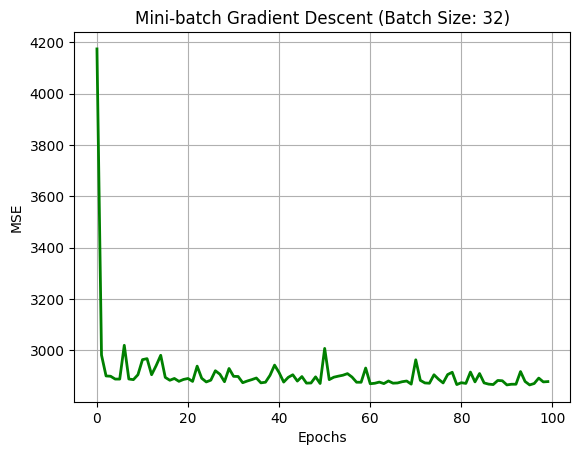

In [2]:
plt.plot(range(epochs), loss_history, color='green', lw=2)
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title(f"Mini-batch Gradient Descent (Batch Size: {batch_size})")
plt.grid(True)
plt.show()